## Configure data frame

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker

BASE_DIR = Path.cwd()
EXCEL_FILE = BASE_DIR / "data" / "half_marathon_20260516.ods"
TOPOGRAPHY_FILE = BASE_DIR / "data" / "topography_20260516.png"  # optional; used only if file exists
FIGURES_DIR = BASE_DIR / "outputs"

DATE = EXCEL_FILE.stem.split("_")[-1]  # extracts the date from the file name

In [2]:
# Read data into data frame and fix data types for columns

df = pd.read_excel(EXCEL_FILE, sheet_name="Data", header=0)
df = df[df["Name"].notna() & df["Km"].notna()].copy()  # Filter empry rows
df["Km"] = df["Km"].astype(int)
df["Split_sec"] = df["Split_sec"].astype(int)
df["Cumulative_sec"] = df["Cumulative_sec"].astype(int)
df.head()

,Name,Km,Split_Time,Cumulative_Time,Split_sec,Cumulative_sec
0,Santeri Salomaa,1,00:06:01,00:06:01,361,361
1,Santeri Salomaa,2,00:06:28,00:12:29,388,749
2,Santeri Salomaa,3,00:06:08,00:18:37,368,1117
3,Santeri Salomaa,4,00:06:09,00:24:46,369,1486
4,Santeri Salomaa,5,00:05:37,00:30:23,337,1823


In [3]:
# Define helper functions for formatting times

def fmt_sec_mmss(sec: float) -> str:
    sec = int(sec)
    m = sec // 60
    s = sec % 60
    return f"{m:02d}:{s:02d}"

def fmt_sec_hhmmss(sec: float) -> str:
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


# Define format setters compatable with mticker.FuncFormatter later on

def sec_formatter_mmss(x, _):
    return fmt_sec_mmss(x)

def sec_formatter_hhmmss(x, _):
    return fmt_sec_hhmmss(x)

## Show basic stats of each runner

In [4]:
names = df["Name"].unique()
rows = []

for name in names:
    sub = df[df["Name"] == name].sort_values("Km")
    splits = sub["Split_sec"].values
    avg_split = splits.mean()

    rows.append(
        {
            "Name": name,
            "Avg_split_sec": avg_split,  # numeric column for sorting
            "Total (21km)": fmt_sec_hhmmss(splits.sum()),
            "Avg split": fmt_sec_mmss(avg_split),
            "Fastest": f"Km {sub.loc[sub['Split_sec'].idxmin(), 'Km']} ({fmt_sec_mmss(splits.min())})",
            "Slowest": f"Km {sub.loc[sub['Split_sec'].idxmax(), 'Km']} ({fmt_sec_mmss(splits.max())})",
            "Std dev (sec)": round(splits.std(), 1),
        }
    )

summary = (
    pd.DataFrame(rows)
    .sort_values("Avg_split_sec")   # ascending = fastest first
    .drop(columns="Avg_split_sec")
    .set_index("Name")
)

summary

,Total (21km),Avg split,Fastest,Slowest,Std dev (sec)
Name,,,,,
Elias Ervelä,01:54:57,05:28,Km 21 (04:41),Km 1 (06:45),25.8
Elias Heikkilä,01:55:16,05:29,Km 21 (04:54),Km 2 (06:22),21.7
Lauri Pulli,01:56:54,05:34,Km 21 (04:51),Km 2 (06:25),20.5
Santeri Salomaa,01:58:01,05:37,Km 20 (05:09),Km 2 (06:28),20.5


In [5]:
# Save the stats as a png

fig, ax = plt.subplots(figsize=(8, len(summary) * 0.6 + 0.8))
ax.axis("off")

tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.auto_set_column_width(col=list(range(len(summary.columns))))

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#dddddd")
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white")
    elif row % 2 == 0:
        cell.set_facecolor("#f0f4f8")

fig.savefig(FIGURES_DIR / f"runners_summary_{DATE}.png", dpi=150, bbox_inches="tight")
plt.close(fig)

## Configurable target paces

In [6]:
TARGETS = [
    (341, "2 hours pace (5:41/km)", "black")
]

## Plot splits with the (optional) topography image below

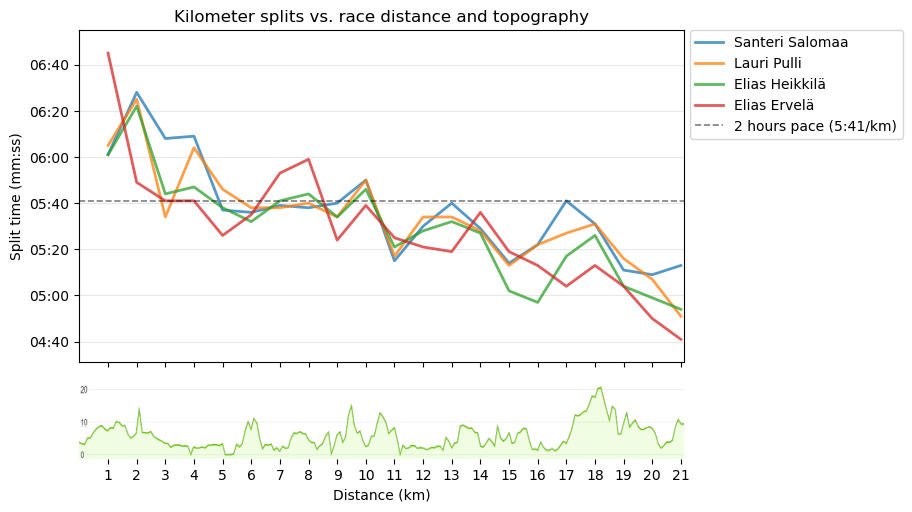

In [12]:
colors = plt.cm.tab10.colors
km_ticks = sorted(df["Km"].unique())
names = sorted(names, key=lambda n: df[df["Name"] == n]["Split_sec"].mean(), reverse=True)

has_topography = Path(TOPOGRAPHY_FILE).exists()

if has_topography:
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(9, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]},
        constrained_layout=True
    )
else:
    fig, ax1 = plt.subplots(
        1, 1,
        figsize=(9, 4),
        constrained_layout=True
    )
    ax2 = None  # explicitly disable

# --- main split plot ---
for i, name in enumerate(names):
    sub = df[df["Name"] == name].sort_values("Km")
    ax1.plot(
        sub["Km"],
        sub["Split_sec"],
        color=colors[i],
        linewidth=2,
        alpha=0.75,
        label=name
    )

for sec, label, color in TARGETS:
    ax1.axhline(
        sec,
        color=color,
        linewidth=1.2,
        linestyle="--",
        label=label,
        alpha=0.5
    )

ax1.set_ylabel("Split time (mm:ss)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(sec_formatter_mmss))

pad = 10
ax1.set_ylim(df["Split_sec"].min() - pad, df["Split_sec"].max() + pad)
ax1.grid(axis="y", alpha=0.3)
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax1.set_xticks(km_ticks)
ax1.tick_params(axis="x", rotation=45)
if has_topography:
    ax1.set_title("Kilometer splits vs. race distance and topography")
else:
    ax1.set_title("Kilometer splits vs. race distance")

# --- topography panel (only if available) ---
if ax2 is not None:
    img = mpimg.imread(TOPOGRAPHY_FILE)
    ax2.imshow(img, aspect="auto", extent=[0, 21.1, 0, 1], origin="upper")
    ax2.set_xlim(0, 21.1)
    ax2.set_ylim(0, 1)
    ax2.set_yticks([])
    ax2.set_xlabel("Distance (km)")

    for spine in ax2.spines.values():
        spine.set_visible(False)

plt.savefig(FIGURES_DIR / f"km_splits_{DATE}.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot pace deviation from personal average

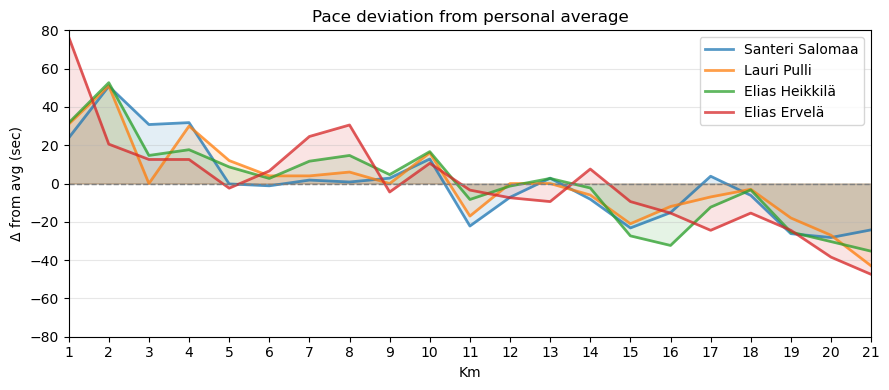

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

for i, name in enumerate(names):
    sub = df[df["Name"] == name].sort_values("Km")
    delta = sub["Split_sec"] - sub["Split_sec"].mean()
    ax.plot(
        sub["Km"],
        delta,
        label=name,
        color=colors[i],
        linewidth=2,
        markersize=6,
        alpha=0.75,
    )
    ax.fill_between(sub["Km"], delta, alpha=0.12, color=colors[i])

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Pace deviation from personal average")
ax.set_xlabel("Km")
ax.set_ylabel("\u0394 from avg (sec)")
ax.set_xlim(1, 21)
ax.set_xticks(range(1, 22))
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(-80, 80)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"pace_deviation_{DATE}.png", dpi=150, bbox_inches="tight")
plt.show()